# 🌊 GFM Flood & Infrastructure Risk Analyzer

### Introduction

The **Global Flood Monitoring (GFM)** system by the **Copernicus Emergency Management Service (CEMS)** provides near-real-time flood information derived from Sentinel-1 radar imagery.  
These products enable rapid assessment of flood extent and dynamics anywhere on Earth — independent of cloud cover or daylight.

This notebook demonstrates how to overlay **GFM flood data** with **infrastructure from OpenStreetMap** to identify facilities at risk during flood events.

### Storyline

Imagine this:  
It's July 2025 and heavy rainfall hits Pakistan.  
The GFM system detects water spreading across the landscape, but decision-makers need to know:  

**\"Which parts of our infrastructure are at risk?\"**\n
This workflow proceeds step by step:

1. **Draw your Area of Interest (AOI)** — Pick a city, river catchment, or industrial zone directly on the map.  
2. **Select a time window** — Load all available flood layers from the GFM STAC archive.  
3. **Generate maximum flood rasters** — Compute the maximum Flood Extent, Exclusion mask, and Likelihood (0–100%) from [GFM Product Output Layers](https://extwiki.eodc.eu/GFM/PUM/Products).  
4. **Overlay with infrastructure** — Fetch infrastructure points from OpenStreetMap (hospitals, schools, bus stops, etc.).  
5. **Impact analysis** — At each facility, extract flood values: Was it flooded? With what likelihood? How often?  
6. **Export results** — Generate GeoTIFFs, CSV tables (`facilities_results.csv`), and interactive maps.

### Purpose

This notebook provides a **compact end-to-end workflow** for infrastructure risk assessment:

- Convert temporal flood rasters into maximum-extent summary layers.  
- Overlay flood data with critical infrastructure locations.  
- Generate actionable insights for emergency planners and decision-makers.  
- Export publication-ready or dashboard-ready maps and tables.

Such processing can be applied to any AOI, from local river basins to continental scales,  
supporting flood-risk assessment, post-event mapping, and infrastructure resilience planning within the **CLIMAAX** or **CEMS-GFM** frameworks.


## Preparation of work for Google Colab

In [1]:
# Google Colab setup: install missing libs and verify imports
import sys, subprocess, importlib

# map: import_module -> pip_package
REQS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "xarray": "xarray",
    "geopandas": "geopandas",
    "requests": "requests",
    "folium": "folium",
    "rioxarray": "rioxarray",
    "rasterio": "rasterio",
    "PIL": "pillow",
    "shapely": "shapely",
    "pyproj": "pyproj",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
    "pystac_client": "pystac-client",
    "odc.stac": "odc-stac",
    "ipywidgets": "ipywidgets",
    "ipyleaflet": "ipyleaflet",
    # optional, useful for GeoPandas I/O
    "fiona": "fiona",
}

missing = []
for mod, pip_name in REQS.items():
    try:
        importlib.import_module(mod)
    except Exception:
        missing.append(pip_name)

if missing:
    print("Installing:", ", ".join(sorted(set(missing))))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U"] + sorted(set(missing)))
else:
    print("All required packages are already installed.")

# Colab: enable widget manager for ipywidgets/ipyleaflet
try:
    from google.colab import output  # type: ignore
    output.enable_custom_widget_manager()
    print("Colab widget manager enabled.")
except Exception:
    pass

# Verify imports used in your script
try:
    import os, io, base64, time, warnings, json
    from datetime import date, timedelta
    from textwrap import dedent

    import numpy as np
    import pandas as pd
    import xarray as xr
    import geopandas as gpd

    import requests
    import folium
    import rioxarray
    from PIL import Image

    from shapely.geometry import box, shape, Point
    import pyproj
    from pyproj import Transformer
    from matplotlib import cm
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm

    # STAC
    from pystac_client import Client
    import odc.stac

    # Widgets / map
    import ipywidgets as widgets
    from ipyleaflet import Map, DrawControl, Rectangle

    warnings.filterwarnings("ignore", category=FutureWarning)

    # STAC constants
    STAC_URL = "https://stac.eodc.eu/api/v1"
    COLLECTION_ID = "GFM"

    # brief version report
    def ver(mod_name):
        try:
            m = importlib.import_module(mod_name)
            return getattr(m, "__version__", "unknown")
        except Exception:
            return "not found"

    report = {
        "numpy": ver("numpy"),
        "pandas": ver("pandas"),
        "xarray": ver("xarray"),
        "geopandas": ver("geopandas"),
        "rasterio": ver("rasterio"),
        "rioxarray": ver("rioxarray"),
        "shapely": ver("shapely"),
        "pyproj": ver("pyproj"),
        "matplotlib": ver("matplotlib"),
        "tqdm": ver("tqdm"),
        "pystac-client": ver("pystac_client"),
        "odc-stac": ver("odc.stac"),
        "ipywidgets": ver("ipywidgets"),
        "ipyleaflet": ver("ipyleaflet"),
        "fiona": ver("fiona"),
    }
    print("Verification succeeded. Versions:", report)
except Exception as e:
    print("Verification failed:", repr(e))
    raise

All required packages are already installed.
Verification succeeded. Versions: {'numpy': '2.3.5', 'pandas': '2.3.3', 'xarray': '2025.11.0', 'geopandas': '1.1.1', 'rasterio': '1.4.3', 'rioxarray': '0.19.0', 'shapely': '2.0.7', 'pyproj': '3.7.1', 'matplotlib': '3.10.8', 'tqdm': '4.67.1', 'pystac-client': '0.9.0', 'odc-stac': '0.4.1', 'ipywidgets': '8.1.8', 'ipyleaflet': '0.20.0', 'fiona': '1.10.1'}


## Load libraries and set STAC

In [2]:
import os, io, base64, time, warnings, json
from datetime import date, timedelta
from textwrap import dedent

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

import requests
import folium
import rioxarray
from PIL import Image

from shapely.geometry import box, shape, Point
import pyproj
from pyproj import Transformer
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# STAC
from pystac_client import Client
import odc.stac

# Widgets / map
import ipywidgets as widgets
from ipyleaflet import Map, DrawControl, Rectangle

warnings.filterwarnings("ignore", category=FutureWarning)

## Draw an Area of Interest (AOI) 🗺️

Use the map below to **draw a rectangle** around the area you want to analyze.  

⚠️ Rules for drawing:  
- Only rectangles are allowed (no polygons, lines or circles).  
- To keep things efficient, a **size limit** is enforced:  
  – the sum of width + height of the rectangle must be ≤ `MAX_SIZE` degrees.  
- If your selection is too large, you'll see a warning and the AOI won't be accepted.  

After drawing, the **selected bounding box** (min/max longitude/latitude) will be printed under the map.  
The default bounding box is shown in **green**, and your new selection will appear in **red**.


In [3]:

from shapely.geometry import shape

# Create map
m = Map(center=(32.1, 74.3), zoom=9)

# Accept only rectangle
draw_control = DrawControl(
    rectangle={"shapeOptions": {"color": "#3388ff", "fillOpacity": 0.1}},
    polygon={}, circle={}, circlemarker={}, polyline={}
)

output = widgets.Output()

# Max allowed size (width + height in degrees)
MAX_SIZE = 2

# Default bbox (minx, miny, maxx, maxy)
#default_bbox = (73.190568, 31.977913, 73.759883, 32.225119)
default_bbox = (73.34404, 32.026688, 73.541794, 32.093028)

# Keep current selection here
selected_bbox = {
    "minx": default_bbox[0],
    "miny": default_bbox[1],
    "maxx": default_bbox[2],
    "maxy": default_bbox[3]
}

# Draw default rectangle on the map
last_rect = Rectangle(
    bounds=((default_bbox[1], default_bbox[0]), (default_bbox[3], default_bbox[2])),
    color="green",
    fill_opacity=0.2
)
m.add_layer(last_rect)

with output:
    print("Default bounding box:", selected_bbox)

# Callback for draw events
def handle_draw(_, action, geo_json):
    global selected_bbox, last_rect

    # Remove old rectangle
    if last_rect in m.layers:
        m.remove_layer(last_rect)

    if geo_json["geometry"]["type"] == "Polygon":
        geom = shape(geo_json["geometry"])
        minx, miny, maxx, maxy = geom.bounds
        width = maxx - minx
        height = maxy - miny
        size = width + height

        with output:
            output.clear_output()
            if size > MAX_SIZE:
                print(f"⚠️ Bounding box is too big! "
                      f"Max (width+height): {MAX_SIZE}°, "
                      f"currently: {size:.3f}° (width {width:.3f}°, height {height:.3f}°)")
                selected_bbox = {}
            else:
                selected_bbox = {"minx": minx, "miny": miny, "maxx": maxx, "maxy": maxy}
                # Draw new rectangle
                new_rect = Rectangle(bounds=((miny, minx), (maxy, maxx)),
                                     color="red", fill_opacity=0.2)
                m.add_layer(new_rect)
                # Track it
                globals()["last_rect"] = new_rect
                print("Selected bounding box:", selected_bbox)

draw_control.on_draw(handle_draw)
m.add_control(draw_control)

display(m, output)


Map(center=[32.1, 74.3], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

Output()

## Pick a date range 📅

Flood layers are stored **day by day**.  
To analyze a specific flood, you need to know **when the event happened**.  

- Select the start and end dates that cover the flood period.  
- The notebook will load all available GFM flood maps in this range.  


In [4]:

from datetime import date, timedelta
from IPython.display import display, clear_output

# DatePickers
start_picker = widgets.DatePicker(
    description="From:",
    value=date(2025, 6, 27),
    disabled=False
)
end_picker = widgets.DatePicker(
    description="To:",
    value=date(2025, 7, 17),
    disabled=False
)
output = widgets.Output()
selected_dates = []

def update_range(change=None):
    global selected_dates
    if start_picker.value and end_picker.value:
        start = start_picker.value
        end = end_picker.value
        with output:
            output.clear_output()
            if start > end:
                print("⚠️ The start date must be earlier than or equal to the end date.")
                selected_dates = []
                return
            selected_dates = [(start + timedelta(days=i)).isoformat()
                              for i in range((end - start).days + 1)]
            print("Selected dates:", selected_dates[:3], "...", selected_dates[-3:] if len(selected_dates) > 3 else selected_dates)

start_picker.observe(update_range, names="value")
end_picker.observe(update_range, names="value")

# Initialize
update_range()

display(widgets.HBox([start_picker, end_picker]), output)


Output()

## Select which bands to load 📊

Flood data comes in **different layers (bands)**, each with a specific meaning:  
- `ensemble_flood_extent` → binary flood map (0 = no flood, 1 = flood)  
- `exclusion_mask` → areas where satellite data cannot reliably detect flooding  
- `ensemble_likelihood` → flood likelihood in % (0–100)  

🔎 Instructions:  
- You can select **one or more bands** from the list (multi-select is supported).  
- Your current selection will be shown in the status box below.  
- By default, **all bands are selected**.


In [5]:

# Available bands
AVAILABLE_BANDS = ["ensemble_flood_extent", "exclusion_mask", "ensemble_likelihood"]

band_selector = widgets.SelectMultiple(
    options=AVAILABLE_BANDS,
    value=AVAILABLE_BANDS,  # default
    description="Bands:",
    style={'description_width': 'initial'},
    rows=len(AVAILABLE_BANDS)
)

output = widgets.Output()

def on_selection_change(change):
    with output:
        clear_output()
        if change["new"]:
            print("✅ Current selection:")
            for b in change["new"]:
                print(f"  • {b}")
        else:
            print("⚠️ No band selected.")

band_selector.observe(on_selection_change, names="value")

display(band_selector, output)
# Print default immediately
on_selection_change({"new": band_selector.value})


SelectMultiple(description='Bands:', index=(0, 1, 2), options=('ensemble_flood_extent', 'exclusion_mask', 'ens…

Output()

## Prepare AOI geometry and time range 🗂️

Before we can query flood data, we need two things:

1. **Area of Interest (AOI):**  
   The rectangle you drew on the map is converted into a Shapely geometry object.  
   – This gives us exact bounding box coordinates (min/max longitude & latitude).  

2. **Time range:**  
   The dates you selected earlier are combined into a start and end date.  
   – This tells the STAC API which flood images to load.  

Both the AOI bounds and the selected time range are printed below for verification.


In [6]:

# Create Shapely geometry for AOI from 'selected_bbox'
if selected_bbox:
    aoi_geometry = box(selected_bbox["minx"], selected_bbox["miny"],
                       selected_bbox["maxx"], selected_bbox["maxy"])
else:
    aoi_geometry = None

# Build time range from selected dates
if 'selected_dates' in globals() and selected_dates:
    time_range = (selected_dates[0], selected_dates[-1])
else:
    time_range = None

print("AOI geometry:", aoi_geometry)
if aoi_geometry:
    print("AOI bounds:", aoi_geometry.bounds)
print("Time range:", time_range)


AOI geometry: POLYGON ((73.541794 32.026688, 73.541794 32.093028, 73.34404 32.093028, 73.34404 32.026688, 73.541794 32.026688))
AOI bounds: (73.34404, 32.026688, 73.541794, 32.093028)
Time range: ('2025-06-27', '2025-07-17')


## STAC search + load 🔍

In this step we connect to the **STAC API** (SpatioTemporal Asset Catalog) at  
[EODC](https://stac.eodc.eu/api/v1) and request flood data from the **GFM collection**.

Process:

1. **Search the catalog:**  
   – Uses your AOI geometry (rectangle) and the selected date range.  
   – Returns all matching flood data items (satellite-derived rasters).  
   – The notebook prints how many items were found and how long the search took.  

2. **Select bands:**  
   – Only the bands you chose earlier are loaded.  

3. **Load rasters:**  
   – Data are loaded lazily via `odc-stac` (efficient, chunked).  
   – The source CRS (coordinate reference system) and resolution are read from metadata.  

4. **Reproject to EPSG:4326 (WGS84):**  
   – Ensures all downstream steps use a common geographic coordinate system.  
   – This makes overlays with OSM and Folium maps work correctly.  

✅ Output:  
– List of STAC items found.  
– Loaded rasters in memory (aligned to your AOI, time range, and selected bands).  


In [7]:
# STAC constants
STAC_URL = "https://stac.eodc.eu/api/v1"
COLLECTION_ID = "GFM"

assert aoi_geometry is not None, "Please draw/select a bounding box first."
assert time_range is not None, "Please choose a valid date range first."

selected_bands = list(band_selector.value) if len(band_selector.value) else ["ensemble_flood_extent"]
print("🔎 Bands to load:", selected_bands, flush=True)

t0 = time.time()
client = Client.open(STAC_URL)
search = client.search(
    collections=[COLLECTION_ID],
    intersects=aoi_geometry.__geo_interface__,
    datetime=f"{time_range[0]}/{time_range[1]}"
)
items = search.item_collection()
print(f"STAC search: {time.time()-t0:.2f}s → {len(items)} items", flush=True)
if len(items) == 0:
    raise RuntimeError("No STAC items found for your AOI/time.")

# CRS & resolution
p = items[0].properties
if "proj:wkt2" in p:
    crs = pyproj.CRS.from_wkt(p["proj:wkt2"])
elif p.get("proj:epsg"):
    crs = pyproj.CRS.from_epsg(int(p["proj:epsg"]))
else:
    crs = pyproj.CRS.from_epsg(4326)
res = p.get("gsd", 20.0)
if isinstance(res, (list, tuple)) and res:
    res = float(res[0])
elif isinstance(res, (int, float)):
    res = float(res)
else:
    res = 20.0
print("Source CRS:", crs, "| Resolution:", res, flush=True)

# LOAD
t1 = time.time()
xx = odc.stac.load(
    items,
    crs=crs,
    bbox=aoi_geometry.bounds,
    bands=selected_bands,
    resolution=res,
    dtype="uint8",
    fail_on_error=False,
)
print(f"lazy load prepared: {time.time()-t1:.2f}s", flush=True)

# reproject to 4326
t2 = time.time()
xx = xx.rio.reproject("EPSG:4326")
print(f"reproject → EPSG:4326: {time.time()-t2:.2f}s", flush=True)


🔎 Bands to load: ['ensemble_flood_extent', 'exclusion_mask', 'ensemble_likelihood']
STAC search: 1.11s → 61 items
Source CRS: PROJCS["Azimuthal_Equidistant",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["false_easting",4340913.84808],PARAMETER["false_northing",4812712.92347],PARAMETER["longitude_of_center",94.0],PARAMETER["latitude_of_center",47.0],UNIT["metre",1,AUTHORITY["EPSG","9001"]]] | Resolution: 20.0
lazy load prepared: 11.41s
reproject → EPSG:4326: 0.51s


## Compute and export rasters ⚙️

For the selected bands, we compute **maximum values over the chosen time range**.  
This gives a single summary raster per band:

- **Flood Extent** → binary mask (0 = dry, 1 = flooded)  
  – A pixel is set to 1 if it was flooded at least once during the period.  
  – Exported as `max_flood_extent.tif`.

- **Exclusion Mask** → binary mask (0 = valid, 1 = excluded)  
  – A pixel is set to 1 if it was excluded in *any* timestep.  
  – Exported as `max_exclusion_mask.tif`.

- **Likelihood** → continuous 0–100 scale  
  – For each pixel, we take the **maximum likelihood** observed across the period.  
  – Exported as `max_likelihood.tif`.

👉 Only the bands you selected earlier are computed and saved.  

All GeoTIFFs are compressed (`LZW`) and ready for use in GIS tools or further processing.


In [8]:

prepared = {}

if "ensemble_flood_extent" in xx:
    print("→ Computing Max Flood …", flush=True)
    flood_binary = xr.where((xx.ensemble_flood_extent != 255) & (xx.ensemble_flood_extent != 0), 1, 0)
    flood_max = xr.where(flood_binary.sum(dim="time") > 0, 1, 0).astype("uint8")
    flood_max.rio.to_raster("max_flood_extent.tif", compress="LZW")
    prepared["Max Flood Extent"] = (flood_max, "Blues")
    print("   saved: max_flood_extent.tif", flush=True)

if "exclusion_mask" in xx:
    print("→ Computing Max Exclusion …", flush=True)
    excl_mask = xx.exclusion_mask == 1
    excl_max = xr.where(excl_mask.sum(dim="time") > 0, 1, 0).astype("uint8")
    excl_max.rio.to_raster("max_exclusion_mask.tif", compress="LZW")
    prepared["Max Exclusion Mask"] = (excl_max, "Greys")
    print("   saved: max_exclusion_mask.tif", flush=True)

if "ensemble_likelihood" in xx:
    print("→ Computing Max Likelihood …", flush=True)
    lik_valid = xx.ensemble_likelihood.where(xx.ensemble_likelihood != 255)
    lik_max = lik_valid.max(dim="time", skipna=True).fillna(255).astype("uint8")
    lik_max.rio.to_raster("max_likelihood.tif", compress="LZW")
    prepared["Max Likelihood (0–100)"] = (lik_max, "Reds")
    print("   saved: max_likelihood.tif", flush=True)

print("Prepared layers:", list(prepared.keys()))


→ Computing Max Flood …
   saved: max_flood_extent.tif
→ Computing Max Exclusion …
   saved: max_exclusion_mask.tif
→ Computing Max Likelihood …
   saved: max_likelihood.tif
Prepared layers: ['Max Flood Extent', 'Max Exclusion Mask', 'Max Likelihood (0–100)']


## Preview computed rasters

To quickly check the results, we generate **inline previews** of the exported rasters:  

- Each selected layer (`Flood`, `Exclusion`, `Likelihood`) is shown in its own panel.  
- **Flood** and **Exclusion** are binary masks (no colorbar).  
- **Likelihood** is continuous (0–100) and therefore displayed with a colorbar.  

⚠️ These previews are meant for quick inspection inside the notebook.  
For high-resolution analysis, use the exported GeoTIFFs (`.tif`) in GIS software.


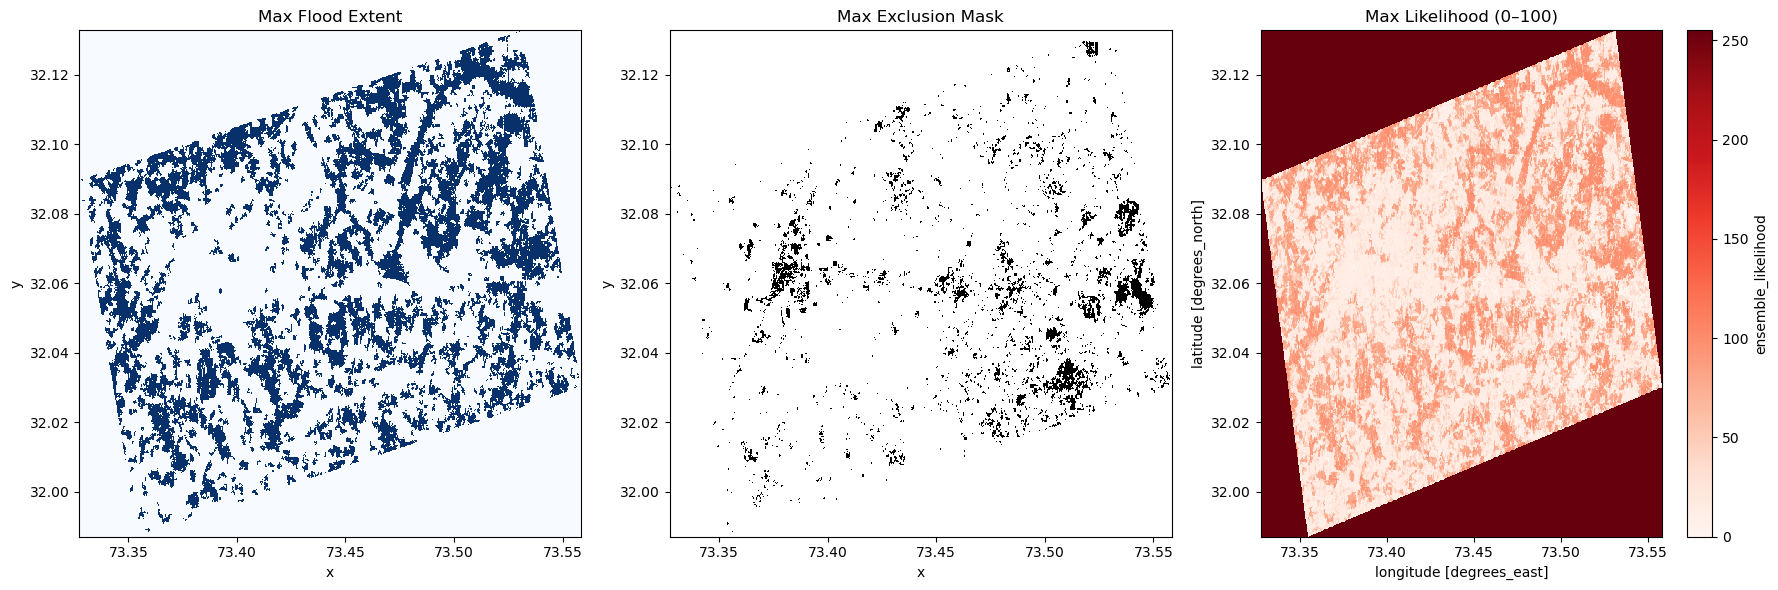

In [9]:

n = len(prepared)
if n:
    fig, axs = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1:
        axs = [axs]

    for ax, (title, (arr, cmap)) in zip(axs, prepared.items()):
        if "Likelihood" in title:
            arr.plot(ax=ax, cmap=cmap, add_colorbar=True)
        else:
            arr.plot(ax=ax, cmap=cmap, add_colorbar=False)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print("No layers to preview (check your band selection).")


## Select OSM category 

Now we connect to **OpenStreetMap (OSM)** via the Overpass API to fetch real-world facilities.  

- Use the dropdown to pick which type of objects you want to analyze:  
  – 🚌 Bus stops  
  – ☕ Cafés  
  – 🚲 Bicycle parking  
  – ⛽ Fuel stations  
  – 🏫 Schools  
  – 💊 Pharmacies  
  – 🍽️ Restaurants  
  – 🏥 Hospitals  
  – 🌳 Parks  
  – 🛝 Playgrounds  

- Your current choice is shown in the status box below (including the raw OSM filter code).  
- The notebook will later **overlay these points with flood rasters**, so you can see which facilities are impacted.  

Default: **Bus stops** are selected on first run, but you can change the category anytime.


In [10]:
OSM_OPTIONS = {
    "Bus stops":        ('["highway"="bus_stop"]',        "bus_stops"),
    "Cafés":            ('["amenity"="cafe"]',            "cafes"),
    "Bicycle parking":  ('["amenity"="bicycle_parking"]', "bicycle_parking"),
    "Fuel stations":    ('["amenity"="fuel"]',            "fuel"),
    "Schools":          ('["amenity"="school"]',          "schools"),
    "Pharmacies":       ('["amenity"="pharmacy"]',        "pharmacies"),
    "Restaurants":      ('["amenity"="restaurant"]',      "restaurants"),
    "Hospitals":        ('["amenity"="hospital"]',        "hospitals"),
    "Parks":            ('["leisure"="park"]',            "parks"),
    "Playgrounds":      ('["leisure"="playground"]',      "playgrounds"),
}

# Default selection on first run
if 'OSM_CATEGORY_FILTER' not in globals() or 'OSM_LAYER_NAME' not in globals():
    OSM_CATEGORY_FILTER, OSM_LAYER_NAME = OSM_OPTIONS["Bus stops"]

dd = widgets.Dropdown(
    options=list(OSM_OPTIONS.keys()),
    value="Bus stops",
    description="OSM category:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="360px"),
)

status = widgets.HTML()

def _apply_selection(name: str):
    global OSM_CATEGORY_FILTER, OSM_LAYER_NAME
    OSM_CATEGORY_FILTER, OSM_LAYER_NAME = OSM_OPTIONS[name]
    status.value = (
        f"<b>Selected:</b> {name} → "
        f"<code>{OSM_CATEGORY_FILTER}</code>, layer "
        f"<code>{OSM_LAYER_NAME}</code>"
    )

def _on_change(change):
    if change["name"] == "value" and change["type"] == "change":
        _apply_selection(change["new"])

dd.observe(_on_change, names="value")
_apply_selection(dd.value)  # initialize status
display(widgets.VBox([dd, status]))


## Fetch OSM facilities inside AOI

In this step we connect to **OpenStreetMap (OSM)** using the Overpass API and download 
all facilities of the selected category (e.g. bus stops, schools, hospitals) within 
your **Area of Interest (AOI)**.

Process:
1. **Build Overpass query**  
   – Uses your AOI bounding box (min/max lat/lon).  
   – Applies the category filter (e.g. `["highway"="bus_stop"]`).  

2. **Download & parse features**  
   – Fetches all OSM nodes, ways, and relations.  
   – Extracts coordinates (node positions or polygon centers).  
   – Keeps the `name` tag if available.  

3. **Convert to GeoDataFrame**  
   – Stores all features with geometry in EPSG:4326 (WGS84).  
   – Clips them to your AOI for safety.  

4. **Export results**  
   – GeoPackage (`.gpkg`) for GIS tools.  
   – CSV (`.csv`) with name + coordinates for spreadsheets or quick checks.  

✅ Output:  
– Summary in the notebook: how many features were found and kept inside the AOI.  
– Optional preview of the first rows for inspection.  

ℹ️ If no features are found, the notebook will let you know and skip saving.


In [11]:
assert 'aoi_geometry' in globals() and aoi_geometry is not None, "AOI is not set."
minx, miny, maxx, maxy = aoi_geometry.bounds

# fallback if Cell 1 hasn’t been executed yet
OSM_CATEGORY_FILTER = globals().get('OSM_CATEGORY_FILTER', '["highway"="bus_stop"]')
OSM_LAYER_NAME      = globals().get('OSM_LAYER_NAME', 'osm_layer')

query = f"""
[out:json][timeout:60];
(
  node{OSM_CATEGORY_FILTER}({miny},{minx},{maxy},{maxx});
  way{OSM_CATEGORY_FILTER}({miny},{minx},{maxy},{maxx});
  relation{OSM_CATEGORY_FILTER}({miny},{minx},{maxy},{maxx});
);
out center tags;
"""

print(f"🔽 Downloading from Overpass… filter={OSM_CATEGORY_FILTER}", flush=True)
url = "https://overpass-api.de/api/interpreter"
r = requests.get(url, params={"data": query})
r.raise_for_status()
data = r.json()
elements = data.get("elements", [])
print(f"✅ Download complete, elements: {len(elements)}", flush=True)

# Convert to GeoDataFrame (nodes + centers of ways/relations)
features = []
for el in elements:
    typ = el.get("type")
    lon = lat = None
    if typ == "node":
        lon, lat = el.get("lon"), el.get("lat")
    else:
        c = el.get("center")
        if c:
            lon, lat = c.get("lon"), c.get("lat")

    if lon is None or lat is None:
        continue

    name = el.get("tags", {}).get("name", "")
    features.append({
        "name": name,
        "longitude": float(lon),
        "latitude": float(lat),
        "geometry": Point(float(lon), float(lat))
    })

if features:
    gdf = gpd.GeoDataFrame(features, geometry="geometry", crs="EPSG:4326")
else:
    # empty table with correct geometry/CRS
    gdf = gpd.GeoDataFrame(columns=["name", "longitude", "latitude", "geometry"],
                           geometry="geometry", crs="EPSG:4326")

print(f"📦 Parsed features: {len(gdf)}", flush=True)

# Safety clip to AOI
if len(gdf):
    gdf_clip = gdf[gdf.geometry.within(aoi_geometry)].copy()
else:
    gdf_clip = gdf.copy()

print(f"📍 Features inside AOI: {len(gdf_clip)}", flush=True)

# Export (layer names)
gpkg_path = f"{OSM_LAYER_NAME}.gpkg"
csv_path  = f"{OSM_LAYER_NAME}.csv"

# Save only if not empty – otherwise clear message
if len(gdf_clip):
    gdf_clip.to_file(gpkg_path, layer=OSM_LAYER_NAME, driver="GPKG")
    gdf_clip[['name', 'latitude', 'longitude']].to_csv(csv_path, index=False)
    print(f"💾 Saved: {gpkg_path}, {csv_path}", flush=True)
else:
    print("ℹ️ Nothing to save (no features in AOI).", flush=True)

# (optional) preview first rows
try:
    display(gdf_clip.head())
except Exception:
    pass


🔽 Downloading from Overpass… filter=["highway"="bus_stop"]
✅ Download complete, elements: 5
📦 Parsed features: 5
📍 Features inside AOI: 5
💾 Saved: bus_stops.gpkg, bus_stops.csv


,name,longitude,latitude,geometry
0,رسولپور تارڑ بس سٹاپ,73.462810,32.058374,POINT (73.46281 32.05837)
1,نواں شہر بس سٹاپ,73.482490,32.058627,POINT (73.48249 32.05863)
2,سولنگیں کھرل بس سٹاپ,73.424936,32.060850,POINT (73.42494 32.06085)
3,ٹھٹھہ گاہرہ بس سٹاپ,73.501181,32.060586,POINT (73.50118 32.06059)
4,مزکو چوک بس سٹاپ,73.408137,32.062531,POINT (73.40814 32.06253)


## Summarize flood impact at OSM facilities

Now we combine the **flood rasters** with the **OSM points** (e.g. bus stops, schools, hospitals) 
to evaluate which facilities were affected.

Steps:

1. **Load rasters**  
   – Open the previously exported GeoTIFFs (`max_flood_extent.tif`, `max_exclusion_mask.tif`, `max_likelihood.tif`).  
   – Skip missing rasters safely.  

2. **Load facility points**  
   – Read the CSV exported from the OSM step (default = `OSM_LAYER_NAME.csv`).  
   – Must contain at least `latitude` and `longitude`.  

3. **Check raster values around each point**  
   – For each facility, define a small buffer (~500 m square).  
   – Clip the rasters to this AOI and compute statistics:  
     - **Flood / Exclusion**: binary flag (0/1) and % of affected pixels.  
     - **Likelihood**: mean, max, min values (0–100).  

4. **Build results table**  
   – One row per facility.  
   – Columns include facility name, coordinates, and flood/exclusion/likelihood values.  

5. **Sort & export**  
   – Facilities are sorted by highest flood likelihood (or by affected % if likelihood not available).  
   – Results saved as `facilities_results.csv`.  
   – First rows previewed below in the notebook.  

✅ Output:  
– `facilities_results.csv` ready for spreadsheets, reporting, or further analysis.  
– Quick preview of the top 20 facilities with their flood impact indicators.


In [12]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ----------- Inputs & band selection -----------
# From widget (if exists), otherwise empty list
selected_bands = list(globals().get("band_selector", type("X",(object,),{"value":()})).value)

# Mapping from band names to internal keys and file paths
BAND_MAP = {
    "ensemble_flood_extent": ("flood",      "max_flood_extent.tif"),
    "exclusion_mask":        ("excluded",   "max_exclusion_mask.tif"),
    "ensemble_likelihood":   ("likelihood", "max_likelihood.tif"),
}
specs = [BAND_MAP[b] for b in selected_bands if b in BAND_MAP]

print(f"🎛️ Selected bands: {selected_bands or '[]'}", flush=True)
if not specs:
    print("⚠️ No rasters selected → nothing will be processed.", flush=True)


# ----------- Load rasters (safe) -----------
RASTERS = {}  # key -> DataArray

def _open_raster_safe(path: str, fallback_crs=None):
    if not os.path.exists(path):
        print(f"Missing raster: {path}", flush=True)
        return None
    try:
        da = rioxarray.open_rasterio(path, masked=True).squeeze()
        if da.rio.crs is None:
            if fallback_crs is not None:
                print(f"Raster has no CRS: {path} -> assigning {fallback_crs}", flush=True)
                da = da.rio.write_crs(fallback_crs, inplace=False)
            else:
                print(f"Raster has no CRS: {path} -> skipping", flush=True)
                return None
        return da
    except Exception as e:
        print(f"Failed to open {path}: {e}", flush=True)
        return None

# Try to carry over CRS from the first raster that has one (or default to EPSG:4326)
fallback_crs = None
for _, path in specs:
    if os.path.exists(path):
        try:
            tmp = rioxarray.open_rasterio(path, masked=True).squeeze()
            if tmp.rio.crs is not None:
                fallback_crs = tmp.rio.crs
                break
        except Exception:
            continue
if fallback_crs is None:
    fallback_crs = "EPSG:4326"

for key, path in specs:
    da = _open_raster_safe(path, fallback_crs=fallback_crs)
    if da is not None:
        RASTERS[key] = da
        nod = da.rio.nodata
        print(f"Loaded {path} as '{key}' | shape={tuple(da.shape)} crs={da.rio.crs} nodata={nod}", flush=True)

if not RASTERS:
    print("No rasters loaded. Stopping.", flush=True)

# ----------- Parameters & helper functions -----------
AOI_SIDE = 0.005  # ~500 m at mid-latitudes (in degrees)

def _reproject_bounds(bounds, src_crs, dst_crs):
    """Transform bbox between CRS (always_xy=True → (lon,lat))."""
    if str(src_crs) == str(dst_crs):
        return bounds
    tr = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    minx, miny, maxx, maxy = bounds
    x1, y1 = tr.transform(minx, miny)
    x2, y2 = tr.transform(maxx, maxy)
    return (min(x1,x2), min(y1,y2), max(x1,x2), max(y1,y2))

def _to_numpy_masked(da):
    """Xarray → numpy, NoData → NaN, masked → NaN."""
    vals = da.values
    if isinstance(vals, np.ma.MaskedArray):
        arr = vals.filled(np.nan).astype("float32", copy=False)
    else:
        arr = vals.astype("float32", copy=False)
    nod = da.rio.nodata
    if nod is not None:
        arr = np.where(arr == nod, np.nan, arr)
    return arr

def check_point_from_rasters(lat, lon):
    results = {}
    half = AOI_SIDE / 2.0
    aoi4326 = box(lon - half, lat - half, lon + half, lat + half)

    for key, da in RASTERS.items():
        try:
            # reproject bbox → raster CRS
            bb = _reproject_bounds(aoi4326.bounds, "EPSG:4326", da.rio.crs)
            crop = da.rio.clip_box(*bb)

            if crop.size == 0:
                results[key] = {"flag": 0, "frac": 0.0}
                if key == "likelihood":
                    results[key].update({"mean": np.nan, "max": np.nan, "min": np.nan})
                continue

            arr = _to_numpy_masked(crop)
            valid = np.isfinite(arr)
            n_valid = int(valid.sum())
            if n_valid == 0:
                results[key] = {"flag": 0, "frac": 0.0}
                if key == "likelihood":
                    results[key].update({"mean": np.nan, "max": np.nan, "min": np.nan})
                continue

            if key in ("flood", "excluded"):
                # binary: treat > 0.5 as 1
                bin_mask = (arr > 0.5) & valid
                frac = float(bin_mask.sum() / n_valid)
                results[key] = {"flag": int(frac > 0), "frac": frac}

            elif key == "likelihood":
                vals = arr[valid]
                results[key] = {
                    "mean": float(np.mean(vals)) if vals.size else np.nan,
                    "max":  float(np.max(vals))  if vals.size else np.nan,
                    "min":  float(np.min(vals))  if vals.size else np.nan
                }

            else:
                # generic continuous raster → presence > 0
                bin_mask = (arr > 0) & valid
                frac = float(bin_mask.sum() / n_valid)
                results[key] = {"flag": int(frac > 0), "frac": frac}

        except Exception as e:
            print(f"⚠️ Clip/compute failed for '{key}': {e}", flush=True)
            results[key] = {"flag": 0, "frac": 0.0}
            if key == "likelihood":
                results[key].update({"mean": np.nan, "max": np.nan, "min": np.nan})
    return results

# ----------- Load points from CSV -----------
# Prefer output from OSM cell (OSM_LAYER_NAME.csv), otherwise fallback
OSM_LAYER_NAME = globals().get("OSM_LAYER_NAME", "bus_stops").replace(".csv", "")

candidates = [f"{OSM_LAYER_NAME}.csv", "bus_stops.csv", "bus_stops_bbox.csv"]
INPUT_CSV = next((p for p in candidates if os.path.exists(p)), None)
OUTPUT_CSV = "facilities_results.csv"

if INPUT_CSV is None:
    raise FileNotFoundError("No input CSV found (OSM_LAYER_NAME.csv, bus_stops.csv, or bus_stops_bbox.csv).")

df = pd.read_csv(INPUT_CSV)
if not {"latitude","longitude"}.issubset(df.columns):
    raise ValueError(f"CSV {INPUT_CSV} must contain 'latitude' and 'longitude' columns.")

print(f"📄 INPUT: {INPUT_CSV} | rows={len(df)}", flush=True)

# ----------- Computation -----------
all_records = []
for row in tqdm(df.itertuples(index=False), total=len(df), desc="Processing points"):
    lat = float(getattr(row, "latitude"))
    lon = float(getattr(row, "longitude"))
    res = check_point_from_rasters(lat, lon)

    rec = {
        "name":      getattr(row, "name", ""),
        "latitude":  lat,
        "longitude": lon,
    }
    for key, vals in res.items():
        if key in ("flood", "excluded"):
            rec[f"{key}"]     = vals.get("flag", 0)
            rec[f"{key}_pct"] = f"{vals.get('frac',0.0)*100:.1f}%"
        elif key == "likelihood":
            m = vals.get("mean", np.nan); x = vals.get("max", np.nan); n = vals.get("min", np.nan)
            rec["likelihood_mean"] = f"{m:.1f}" if np.isfinite(m) else "N/A"
            rec["likelihood_max"]  = f"{x:.1f}" if np.isfinite(x) else "N/A"
            rec["likelihood_min"]  = f"{n:.1f}" if np.isfinite(n) else "N/A"
        else:
            rec[f"{key}"]     = vals.get("flag", 0)
            rec[f"{key}_pct"] = f"{vals.get('frac',0.0)*100:.1f}%"
    all_records.append(rec)

out_df = pd.DataFrame(all_records)

# ----------- Sorting -----------
sort_key = "likelihood_mean" if "likelihood_mean" in out_df.columns else None
if not sort_key:
    pct_cols = [c for c in out_df.columns if c.endswith("_pct")]
    sort_key = pct_cols[0] if pct_cols else None

if sort_key:
    if sort_key == "likelihood_mean":
        out_df[sort_key] = pd.to_numeric(out_df[sort_key], errors="coerce")
        out_df = out_df.sort_values(by=sort_key, ascending=False)
    else:
        out_df["_sort"] = out_df[sort_key].str.rstrip("%").astype(float)
        out_df = out_df.sort_values(by="_sort", ascending=False).drop(columns=["_sort"])

# ----------- Export & preview -----------
out_df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved: {OUTPUT_CSV} | rows={len(out_df)} | cols={list(out_df.columns)}", flush=True)
out_df.head(20)


🎛️ Selected bands: ['ensemble_flood_extent', 'exclusion_mask', 'ensemble_likelihood']
Raster has no CRS: max_flood_extent.tif -> assigning EPSG:4326
Loaded max_flood_extent.tif as 'flood' | shape=(710, 1126) crs=EPSG:4326 nodata=None
Raster has no CRS: max_exclusion_mask.tif -> assigning EPSG:4326
Loaded max_exclusion_mask.tif as 'excluded' | shape=(710, 1126) crs=EPSG:4326 nodata=None
Loaded max_likelihood.tif as 'likelihood' | shape=(710, 1126) crs=EPSG:4326 nodata=nan
📄 INPUT: bus_stops.csv | rows=5


Processing points:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: facilities_results.csv | rows=5 | cols=['name', 'latitude', 'longitude', 'flood', 'flood_pct', 'excluded', 'excluded_pct', 'likelihood_mean', 'likelihood_max', 'likelihood_min']


,name,latitude,longitude,flood,flood_pct,excluded,excluded_pct,likelihood_mean,likelihood_max,likelihood_min
3,ٹھٹھہ گاہرہ بس سٹاپ,32.060586,73.501181,1,13.2%,1,7.1%,26.4,83.0,0.0
1,نواں شہر بس سٹاپ,32.058627,73.482490,1,13.9%,1,25.8%,24.9,83.0,0.0
4,مزکو چوک بس سٹاپ,32.062531,73.408137,0,0.0%,1,10.3%,15.8,49.0,9.0
0,رسولپور تارڑ بس سٹاپ,32.058374,73.462810,1,2.2%,1,48.8%,14.9,83.0,0.0
2,سولنگیں کھرل بس سٹاپ,32.060850,73.424936,0,0.0%,1,30.9%,13.3,49.0,9.0


# Table Legend

| Column             | Description                                                                 |
|--------------------|-----------------------------------------------------------------------------|
| `name`             | Object name from the CSV (if available).                                    |
| `latitude`         | Point latitude.                                                            |
| `longitude`        | Point longitude.                                                           |
| `flood`            | 1 = at least 1 pixel lies in point AOI, 0 = outside.                  |
| `flood_pct`        | Percentage of valid pixels within the AOI classified as flooded.           |
| `excluded`         | 1 = at least 1 pixel lies in point AOI, 0 = not excluded.                    |
| `excluded_pct`     | Percentage of valid pixels within the AOI classified as excluded.          |
| `likelihood_mean`  | Mean likelihood value within the AOI.                                      |
| `likelihood_max`   | Maximum likelihood value within the AOI.                                   |
| `likelihood_min`   | Minimum likelihood value within the AOI.                                   |

**Notes:**
- Percentages are computed using only valid (non-NoData) pixels.  
- `N/A` indicates no valid pixels were available.  
- The table is sorted by `likelihood_mean` if present, otherwise by the first percentage column.  

## Interactive flood impact map

At this point we combine **all results** into an interactive Folium map:

1. **Raster overlays**  
   – Flood Extent (blue), Exclusion Mask (grey), Likelihood (0–100, red ramp).  
   – Each overlay is created as a semi-transparent PNG and placed on the map.  

2. **OSM facilities**  
   – Points from `facilities_results.csv` are added as markers.  
   – Color scheme:  
     • 🔴 Red = flooded facility  
     • 🟡 Yellow = not flooded (or uncertain)  
   – Clicking a marker shows a popup with detailed values:  
     • Flood/Exclusion flags and percentages  
     • Likelihood mean, max, min (if available)  

3. **Legends & title**  
   – Continuous legend for flood likelihood (0–100).  
   – Binary chips for Flood/Exclusion masks.  
   – A title box on top shows the selected **time range**.  

4. **Layer control**  
   – Use the panel (top-right) to toggle overlays and facilities on/off.  

✅ This map lets you visually inspect:  
– Where floods occurred in your AOI.  
– Which OSM facilities fall into flooded or excluded areas.  
– How likely each location was to be affected.


🗺️ Added: Flood Extent
🗺️ Added: Exclusion Mask
🗺️ Added: Likelihood (0–100)



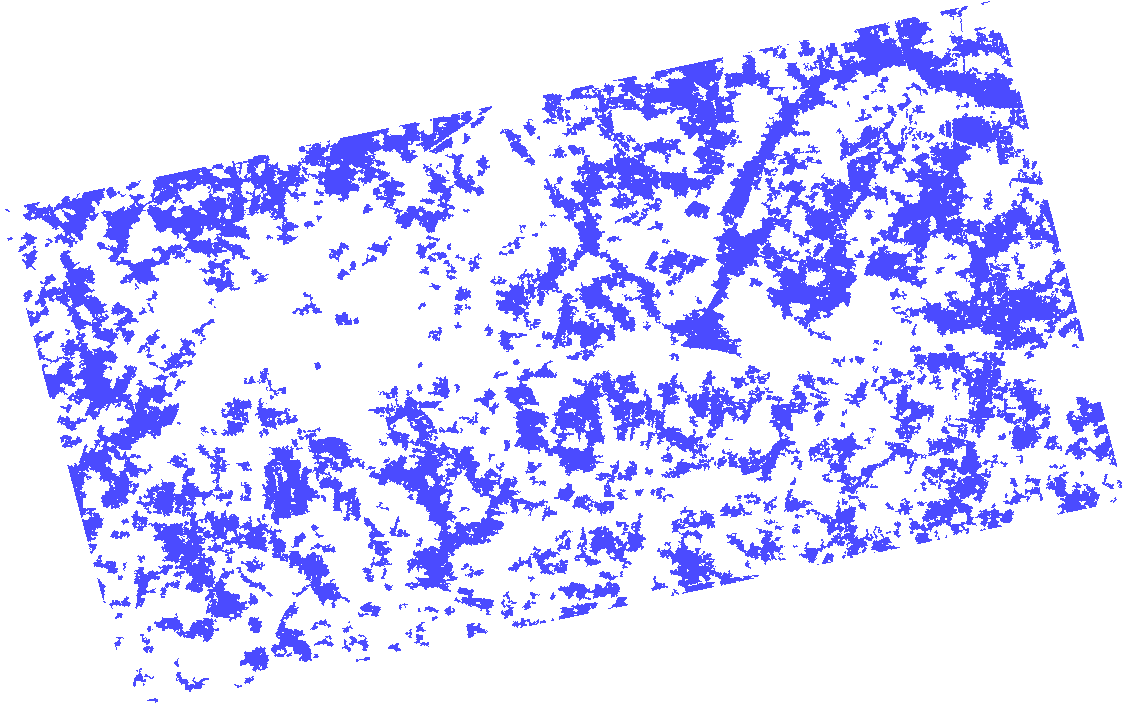
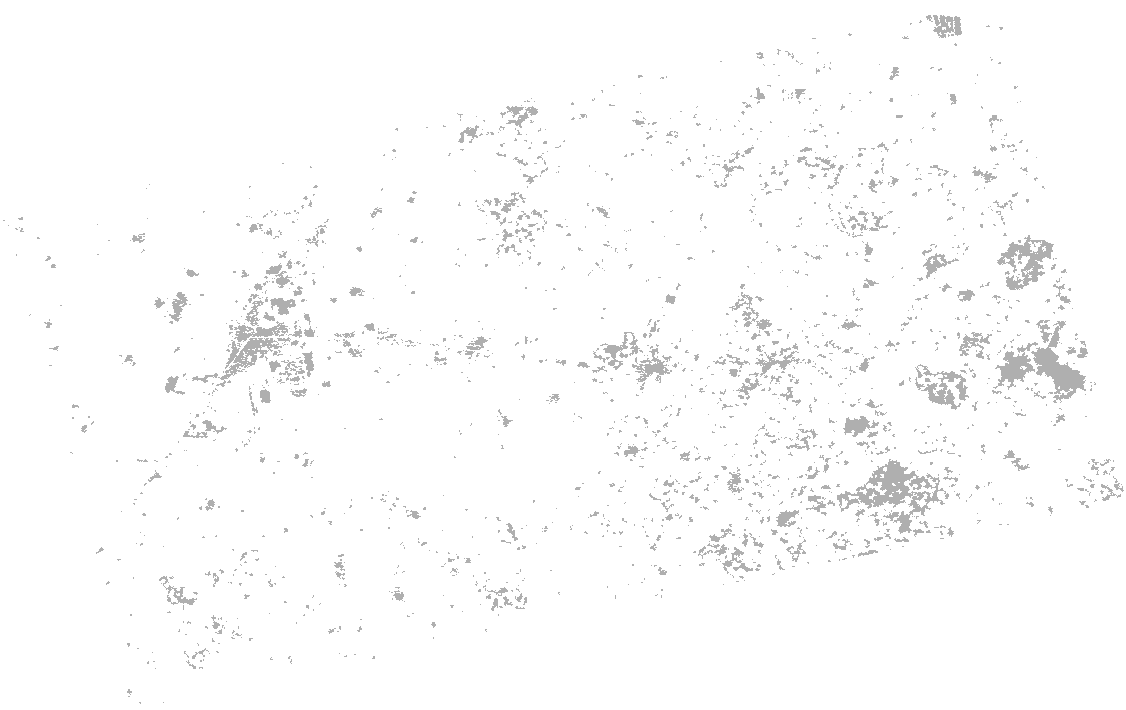
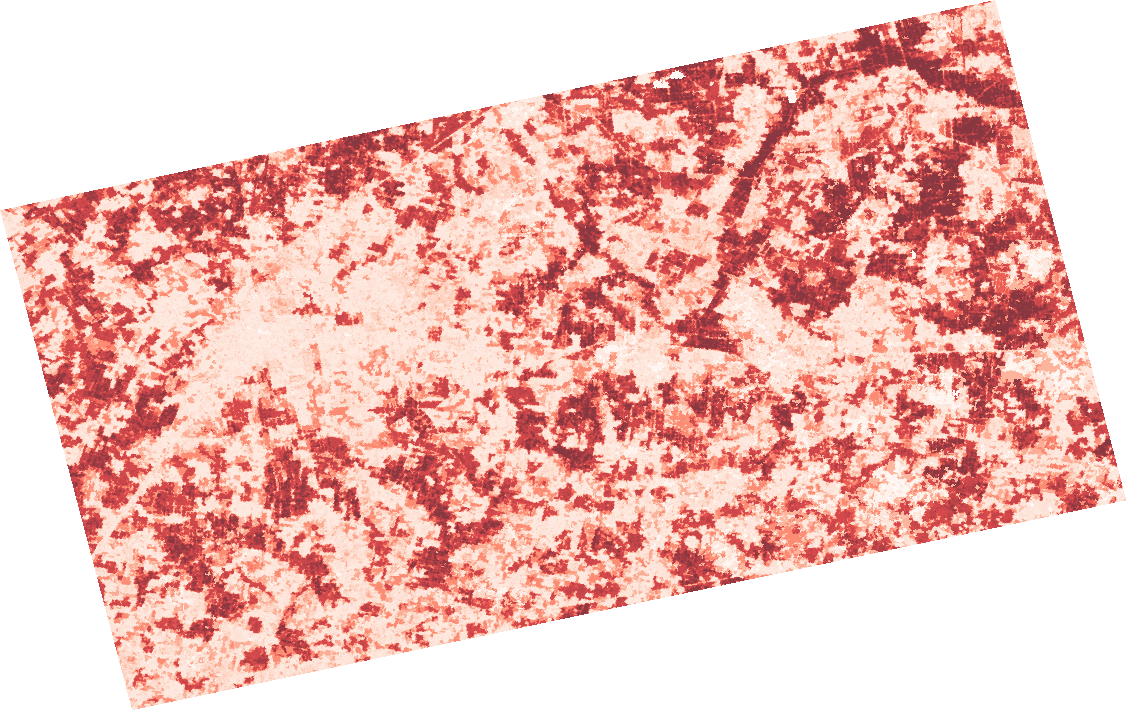

In [13]:
import matplotlib as mpl

# If a selector exists, use it; otherwise fall back to all bands
try:
    selected_bands
except NameError:
    selected_bands = ["ensemble_flood_extent", "exclusion_mask", "ensemble_likelihood"]

# Paths to GeoTIFFs (adjust if your filenames differ)
RASTER_PATHS = {
    "ensemble_flood_extent": "max_flood_extent.tif",
    "exclusion_mask":        "max_exclusion_mask.tif",
    "ensemble_likelihood":   "max_likelihood.tif",
}
# Fallbacks for common likelihood filenames
if (not os.path.exists(RASTER_PATHS["ensemble_likelihood"])
    and os.path.exists("ensemble_likelihood_max.tif")):
    RASTER_PATHS["ensemble_likelihood"] = "ensemble_likelihood_max.tif"
if (not os.path.exists(RASTER_PATHS["ensemble_likelihood"])
    and os.path.exists("max_likelihood_extent.tif")):
    RASTER_PATHS["ensemble_likelihood"] = "max_likelihood_extent.tif"

# Styling / layer types
STYLES = {
    "ensemble_flood_extent": {"type":"binary",     "rgb": (0, 0, 255),   "alpha": 180, "label":"Flood Extent"},
    "exclusion_mask":        {"type":"binary",     "rgb": (128,128,128), "alpha": 160, "label":"Exclusion Mask"},
    "ensemble_likelihood":   {"type":"continuous", "cmap":"Reds",     "alpha": 200, "label":"Likelihood (0–100)"},
}

def _save_binary_overlay(in_tif, out_png, rgb=(0,0,0), alpha=180):
    da = rioxarray.open_rasterio(in_tif).squeeze()
    arr = da.values
    mask = (arr > 0).astype(np.uint8)
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    rgba[...,0], rgba[...,1], rgba[...,2] = rgb
    rgba[...,3] = mask * alpha
    Image.fromarray(rgba).save(out_png)

def _save_continuous_overlay(in_tif, out_png, cmap_name="viridis", alpha=200, vmin=0.0, vmax=100.0):
    da = rioxarray.open_rasterio(in_tif).squeeze()
    vals = da.values.astype("float32")
    nd = da.rio.nodata
    nodemask = np.zeros_like(vals, dtype=bool)
    if nd is not None:
        nodemask |= (vals == nd)
    nodemask |= (vals == 255) | (vals < -1e6) | (vals > 1e6)

    vals = np.clip(vals, vmin, vmax)
    norm = (vals - vmin) / (vmax - vmin + 1e-9)
    norm[nodemask] = np.nan

    cmap = mpl.colormaps.get_cmap(cmap_name)
    rgba = (cmap(np.nan_to_num(norm, nan=0.0)) * 255).astype(np.uint8)
    rgba[..., 3] = np.where(np.isnan(norm), 0, alpha).astype(np.uint8)

    Image.fromarray(rgba).save(out_png)


def _datauri_colormap(cmap_name="viridis", width=240, height=12):
    grad = np.linspace(0, 1, width, dtype="float32")
    grad = np.tile(grad, (height, 1))
    cmap = mpl.colormaps.get_cmap(cmap_name)
    rgba = (cmap(grad) * 255).astype(np.uint8)
    buf = io.BytesIO()
    Image.fromarray(rgba).save(buf, format="PNG")
    return f"data:image/png;base64,{base64.b64encode(buf.getvalue()).decode('ascii')}"


def _rgb_css(rgb):
    r,g,b = rgb
    return f"rgb({r},{g},{b})"

# Prepare overlays
overlays = []
has_continuous = False
for band in selected_bands:
    tif_path = RASTER_PATHS.get(band)
    if not tif_path or not os.path.exists(tif_path):
        print(f"⚠️ Skipping {band}: missing TIF '{tif_path}'")
        continue

    style = STYLES.get(band, {"type":"binary","rgb":(0,0,0),"alpha":160,"label":band})
    png_path = os.path.splitext(tif_path)[0] + "_overlay.png"

    # Always (re)create PNG to avoid stale images
    if os.path.exists(png_path):
        try: os.remove(png_path)
        except: pass

    if style["type"] == "binary":
        _save_binary_overlay(tif_path, png_path, rgb=style["rgb"], alpha=style["alpha"])
    else:
        _save_continuous_overlay(tif_path, png_path, cmap_name=style["cmap"], alpha=style["alpha"], vmin=0, vmax=100)
        has_continuous = True

    da = rioxarray.open_rasterio(tif_path).squeeze()
    minx, miny, maxx, maxy = da.rio.bounds()
    bounds = [[miny, minx], [maxy, maxx]]
    overlays.append({"name": style["label"], "png": png_path, "bounds": bounds, "type": style["type"], "style": style, "tif": tif_path})

if not overlays:
    raise RuntimeError("No overlays to display.")

# Center map on the first overlay
(miny, minx), (maxy, maxx) = overlays[0]["bounds"]
m = folium.Map(location=[(miny+maxy)/2, (minx+maxx)/2], zoom_start=12)

# Add overlays
for ov in overlays:
    folium.raster_layers.ImageOverlay(
        image=ov["png"],               
        bounds=ov["bounds"],
        mercator_project=False,        
        opacity=1.0,                   
        name=ov["name"],
        show=(ov["type"] != "continuous")
    ).add_to(m)
    print(f"🗺️ Added: {ov['name']}")



# Load points table (must include likelihood_mean/max/min if you want them shown)
fac_csv = "facilities_results.csv"
gdf = None
if os.path.exists(fac_csv):
    pts = pd.read_csv(fac_csv)
    gdf = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(pts.longitude, pts.latitude), crs="EPSG:4326")

import re
from folium import IFrame

def _strip_html(s: str) -> str:
    return re.sub(r"<[^>]*>", "", s or "")

def _estimate_popup_width(lines, px_per_char=7.5, pad=50, min_w=220, max_w=520):
    longest = 0
    for ln in lines:
        if not ln:
            continue
        longest = max(longest, len(_strip_html(ln)))
    w = int(longest * px_per_char + pad)
    return max(min_w, min(max_w, w))

def _estimate_popup_height(lines, line_h=18, pad=24, max_h=600):
    n = sum(1 for ln in lines if ln)
    h = int(n * line_h + pad)
    return min(max_h, max(60, h))

# --- Feature layer with adaptive popups (values only from CSV) ---
if gdf is not None:
    grp = folium.FeatureGroup(name="Facilities", show=True)
    bbox_grp = folium.FeatureGroup(name="Sampling window (per point)", show=True)

    # half-side in degrees, pulled from earlier cell if present
    try:
        AOI_SIDE
        half_side = AOI_SIDE / 2.0
    except NameError:
        half_side = 0.0025  # fallback ~250 m

    def safe_str(val):
        if pd.isna(val):
            return None
        s = str(val).strip()
        return s if s and s.upper() != "N/A" else None

    for _, r in gdf.iterrows():
        lat, lon = float(r.latitude), float(r.longitude)
        color = "red" if int(r.get("flood", 0)) == 1 else "yellow"

        like_mean = safe_str(r.get("likelihood_mean", None))
        like_max  = safe_str(r.get("likelihood_max",  None))
        like_min  = safe_str(r.get("likelihood_min",  None))

        lines = [
            f"<b>{safe_str(r.get('name','')) or ''}</b>",
            f"Flooded: {int(r.get('flood',0))}" if "flood" in r else None,
            f"Excluded: {int(r.get('excluded',0))}" if "excluded" in r else None,
            f"Flood %: {safe_str(r.get('flood_pct','')) or ''}" if "flood_pct" in r else None,
            f"Excl. %: {safe_str(r.get('excluded_pct','')) or ''}" if "excluded_pct" in r else None,
        ]
        if like_mean is not None:
            lines.append(f"Likelihood mean: {like_mean}")
        if like_max is not None:
            lines.append(f"Likelihood max: {like_max}")
        if like_min is not None:
            lines.append(f"Likelihood min: {like_min}")

        # WIDE and HEIGHT
        W = _estimate_popup_width(lines)
        H = _estimate_popup_height(lines)

        # HTML
        popup_html = (
            '<div style="font: 12px/1.35 -apple-system,Segoe UI,Roboto,Arial,sans-serif;'
            'padding:6px 8px;white-space:normal;word-break:break-word;">'
            + "<br>".join([ln for ln in lines if ln]) +
            "</div>"
        )

        iframe = IFrame(html=popup_html, width=W, height=H)
        popup = folium.Popup(iframe, max_width=W)

        folium.CircleMarker(
            location=[lat, lon],
            radius=5, color="black",
            fill=True, fill_color=color, fill_opacity=0.7,
            popup=popup
        ).add_to(grp)

        # dashed rectangle representing the computation window around the point
        bbox_bounds = [(lat - half_side, lon - half_side), (lat + half_side, lon + half_side)]
        folium.Rectangle(
            bounds=bbox_bounds,
            color="#ff8800",
            weight=1.5,
            fill=False,
            dash_array="6 4",
            opacity=0.8,
        ).add_to(bbox_grp)

    grp.add_to(m)
    bbox_grp.add_to(m)

# --- Time range title (reads DatePickers if present) ---
from datetime import date

def _range_from_widgets():
    try:
        s = start_picker.value
        e = end_picker.value
        return s, e
    except NameError:
        return None, None

def _format_range(s, e, selected_dates=None):
    if selected_dates and len(selected_dates) >= 1:
        s_iso, e_iso = selected_dates[0], selected_dates[-1]
        n = len(selected_dates)
        return f"{s_iso} → {e_iso} ({n} days)"
    if not s or not e:
        return "not set"
    if s > e:
        return "invalid (start > end)"
    n = (e - s).days + 1
    return f"{s.isoformat()} → {e.isoformat()} ({n} days)"

_s, _e = _range_from_widgets()
try:
    _sel_dates = selected_dates if selected_dates else None
except NameError:
    _sel_dates = None

TIME_RANGE_TITLE = _format_range(_s, _e, _sel_dates)

# Legends
# 1) Likelihood (continuous ramp)
if has_continuous:
    ov_like = next(o for o in overlays if o["type"]=="continuous")
    datauri = _datauri_colormap(ov_like["style"]["cmap"])
    legend_like = f"""
    <div style="
        position: fixed; bottom: 30px; left: 10px; z-index: 9999;
        background: white; padding: 10px 12px; border: 1px solid #ccc; border-radius: 8px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.2); font-size: 12px;">
      <div style="font-weight:600; margin-bottom:6px;">{ov_like['name']}</div>
      <img src="{datauri}" style="width:240px; height:12px; display:block; margin-bottom:4px;" />
      <div style="display:flex; justify-content:space-between;">
        <span>0</span><span>25</span><span>50</span><span>75</span><span>100</span>
      </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_like))

# 2) Flood & Exclusion (binary chips) — only show those actually present
bin_entries = []
for key in ("ensemble_flood_extent", "exclusion_mask"):
    if key in selected_bands and os.path.exists(RASTER_PATHS.get(key,"")):
        style = STYLES[key]
        bin_entries.append((style["label"], _rgb_css(style["rgb"])))

if bin_entries:
    boxes_html = "".join([
        f'<div style="display:flex;align-items:center;margin-bottom:4px;">'
        f'<span style="display:inline-block;width:14px;height:14px;background:{color};'
        f'border:1px solid #333;margin-right:6px;"></span>{label}</div>'
        for (label, color) in bin_entries
    ])
    legend_bin = f"""
    <div style="
        position: fixed; bottom: 120px; left: 10px; z-index: 9999;
        background: white; padding: 10px 12px; border: 1px solid #ccc; border-radius: 8px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.2); font-size: 12px;">
      <div style="font-weight:600; margin-bottom:6px;">Binary overlays</div>
      {boxes_html}
      <div style="margin-top:6px;color:#666;">(meaning: pixel &gt; 0)</div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_bin))

# --- Add top title with time range ---
title_html = f"""
<div style="
position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
z-index: 9999; background: rgba(255,255,255,0.95);
padding: 8px 12px; border: 1px solid #ccc; border-radius: 8px;
font: 14px -apple-system,Segoe UI,Roboto,Arial,sans-serif;">
<strong>Time range:</strong> {TIME_RANGE_TITLE}
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))


folium.LayerControl(collapsed=False).add_to(m)
m
